<a href="https://colab.research.google.com/github/vijaiyavarsha/numpy2/blob/main/Skill_Test_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial Data:
         Date  Temperature (°C)  Humidity (%)  Wind Speed (km/h)  \
0  01-01-2023          3.141445     78.113329           1.734446   
1  02-01-2023         23.816382     52.147763          13.858598   
2  03-01-2023         21.253018     42.400698           3.584790   
3  04-01-2023         27.009025     56.822505           0.655424   
4  05-01-2023         28.474385     52.321631          15.730459   

   Rainfall (mm)  
0       5.229276  
1       3.405370  
2       8.246606  
3       3.909839  
4       7.782806  

Missing Values:
Date                 0
Temperature (°C)     0
Humidity (%)         0
Wind Speed (km/h)    0
Rainfall (mm)        0
dtype: int64

Monthly Average Temperature:
Month
1    14.593329
2    15.680448
3    13.159046
4    13.322376
Name: Temperature (°C), dtype: float64


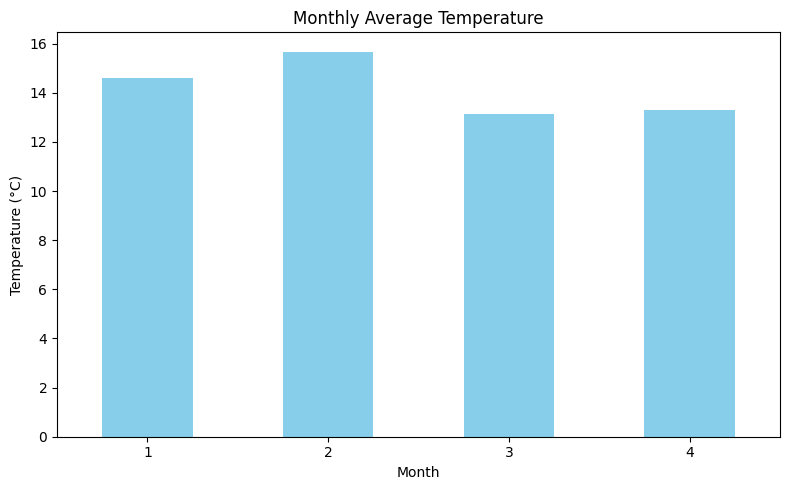

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a dummy weather_data.csv for demonstration
# In a real scenario, you would ensure the file is uploaded or the path is correct.
num_rows = 100
dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_rows, freq='D'))
temperatures = np.random.uniform(low=0, high=30, size=num_rows)
humidity = np.random.uniform(low=40, high=100, size=num_rows)
wind_speed = np.random.uniform(low=0, high=20, size=num_rows)
rainfall = np.random.uniform(low=0, high=10, size=num_rows)

dummy_df = pd.DataFrame({
    'Date': dates.strftime('%d-%m-%Y'),
    'Temperature (°C)': temperatures,
    'Humidity (%)': humidity,
    'Wind Speed (km/h)': wind_speed,
    'Rainfall (mm)': rainfall
})
dummy_df.to_csv('weather_data.csv', index=False)

# Load the dataset
file_path = 'weather_data.csv'
df = pd.read_csv(file_path)

# Display first few rows
print("Initial Data:")
print(df.head())

# -------------------------------
# a. Check for missing values
# -------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values (example: fill with column mean)
df['Temperature (°C)'] = df['Temperature (°C)'].fillna(df['Temperature (°C)'].mean())
df['Humidity (%)'] = df['Humidity (%)'].fillna(df['Humidity (%)'].mean())
df['Wind Speed (km/h)'] = df['Wind Speed (km/h)'].fillna(df['Wind Speed (km/h)'].mean())
df['Rainfall (mm)'] = df['Rainfall (mm)'].fillna(df['Rainfall (mm)'].mean())

# -------------------------------
# b. Monthly average temperature
# -------------------------------
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract month
df['Month'] = df['Date'].dt.month

# Group by month and calculate average temperature
monthly_avg_temp = df.groupby('Month')['Temperature (°C)'].mean()

print("\nMonthly Average Temperature:")
print(monthly_avg_temp)

# -------------------------------
# c. Visualization (Bar Plot)
# -------------------------------
plt.figure(figsize=(8, 5))
monthly_avg_temp.plot(kind='bar', color='skyblue')

plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Import pandas
import pandas as pd
import numpy as np

# Create a dummy student_scores.csv for demonstration
np.random.seed(42) # for reproducibility
num_students = 20
student_ids = range(101, 101 + num_students)
names = [f'Student_{i}' for i in range(1, num_students + 1)]
maths_scores = np.random.randint(30, 100, num_students)
physics_scores = np.random.randint(30, 100, num_students)
chemistry_scores = np.random.randint(30, 100, num_students)

dummy_student_df = pd.DataFrame({
    'Student ID': student_ids,
    'Name': names,
    'Maths': maths_scores,
    'Physics': physics_scores,
    'Chemistry': chemistry_scores
})
dummy_student_df.to_csv('student_scores.csv', index=False)

# Load the dataset
file_path = 'student_scores.csv'
df = pd.read_csv(file_path)

# Display first few rows
print("Initial Data:")
print(df.head())

# -----------------------------------
# a. Summary statistics for subjects
# -----------------------------------
print("\nSummary Statistics:")
summary_stats = df[['Maths', 'Physics', 'Chemistry']].describe()
print(summary_stats)

# -----------------------------------
# b. Average score for each student
# -----------------------------------
df['Average Score'] = df[['Maths', 'Physics', 'Chemistry']].mean(axis=1)

print("\nAverage Score of Each Student:")
print(df[['Student ID', 'Name', 'Average Score']])

# -----------------------------------
# c. Students scoring below 60 in >2 subjects
# -----------------------------------
# Count how many subjects each student scored below 60
df['Below_60_Count'] = (df[['Maths', 'Physics', 'Chemistry']] < 60).sum(axis=1)

# Filter students with more than 2 subjects below 60
low_performers = df[df['Below_60_Count'] > 2]

print("\nStudents scoring below 60 in more than two subjects:")
print(low_performers[['Student ID', 'Name']])

Initial Data:
   Student ID       Name  Maths  Physics  Chemistry
0         101  Student_1     81       71         82
1         102  Student_2     44       89         31
2         103  Student_3     90       44         89
3         104  Student_4     50       91         73
4         105  Student_5     53       91         37

Summary Statistics:
           Maths    Physics  Chemistry
count  20.000000  20.000000  20.000000
mean   63.450000  66.300000  63.000000
std    21.201974  23.015098  22.543525
min    31.000000  32.000000  31.000000
25%    50.000000  43.750000  36.500000
50%    60.500000  73.500000  69.000000
75%    83.250000  89.000000  82.250000
max    93.000000  93.000000  92.000000

Average Score of Each Student:
    Student ID        Name  Average Score
0          101   Student_1      78.000000
1          102   Student_2      54.666667
2          103   Student_3      74.333333
3          104   Student_4      71.333333
4          105   Student_5      60.333333
5          106   S

Initial Data:
   Flight ID    Airline Origin Destination  Departure Delay
0          1  Airline C    ORD         DEN              113
1          2  Airline D    LAX         ATL              110
2          3  Airline A    LAX         DEN              114
3          4  Airline C    DFW         SFO               37
4          5  Airline C    LAX         ATL               52

Summary Statistics for Departure Delays:
count    100.000000
mean      57.250000
std       40.708715
min      -14.000000
25%       21.750000
50%       56.500000
75%       96.000000
max      119.000000
Name: Departure Delay, dtype: float64

Average Delay for Each Airline:
Airline
Airline A    49.050000
Airline B    61.769231
Airline C    67.333333
Airline D    50.733333
Name: Departure Delay, dtype: float64

Most Common Departure (Origin): ORD
Most Common Arrival (Destination): SFO


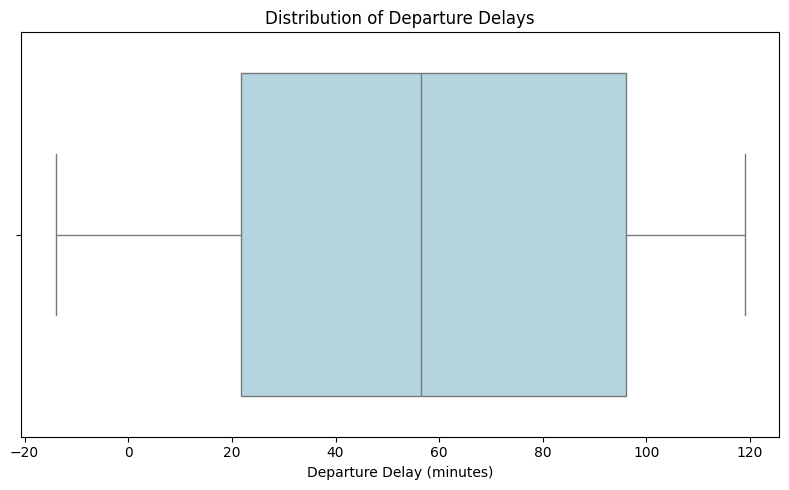

In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a dummy flight_data.csv for demonstration
# In a real scenario, you would ensure the file is uploaded or the path is correct.
num_flights = 100
airlines = ['Airline A', 'Airline B', 'Airline C', 'Airline D']
origins = ['JFK', 'LAX', 'ORD', 'DFW']
destinations = ['SFO', 'MIA', 'DEN', 'ATL']

np.random.seed(42) # for reproducibility
dummy_flight_df = pd.DataFrame({
    'Flight ID': range(1, num_flights + 1),
    'Airline': np.random.choice(airlines, num_flights),
    'Origin': np.random.choice(origins, num_flights),
    'Destination': np.random.choice(destinations, num_flights),
    'Departure Delay': np.random.randint(-15, 120, num_flights) # Delays in minutes, some negative for early
})
dummy_flight_df.to_csv('flight_data.csv', index=False)

# Load dataset
file_path = 'flight_data.csv'
df = pd.read_csv(file_path)

# Display first few rows
print("Initial Data:")
print(df.head())

# -----------------------------------
# a. Summary statistics for departure delays
# -----------------------------------
print("\nSummary Statistics for Departure Delays:")
print(df['Departure Delay'].describe())

# -----------------------------------
# b. Average delay for each airline
# -----------------------------------
avg_delay_airline = df.groupby('Airline')['Departure Delay'].mean()

print("\nAverage Delay for Each Airline:")
print(avg_delay_airline)

# -----------------------------------
# c. Most common departure and arrival destinations
# -----------------------------------
most_common_origin = df['Origin'].mode()[0]
most_common_destination = df['Destination'].mode()[0]

print("\nMost Common Departure (Origin):", most_common_origin)
print("Most Common Arrival (Destination):", most_common_destination)

# -----------------------------------
# d. Box plot for departure delays
# -----------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Departure Delay'], color='lightblue')

plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')

plt.tight_layout()
plt.show()

In [ ]:
import math

# -----------------------------------
# 1. Euclidean Distance (2D)
# Formula: sqrt((x2 - x1)^2 + (y2 - y1)^2)
# -----------------------------------
def euclidean_distance(p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return distance

# Example points
point1 = (2, 3)
point2 = (7, 8)

dist = euclidean_distance(point1, point2)
print("Euclidean Distance:", dist)


# -----------------------------------
# 2. Dot Product of Two Matrices
# -----------------------------------
def matrix_dot_product(A, B):
    # Check if multiplication is possible
    if len(A[0]) != len(B):
        print("Matrix multiplication not possible")
        return None

    # Initialize result matrix with zeros
    result = [[0 for _ in range(len(B[0]))] for _ in range(len(A))]

    # Perform multiplication
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                result[i][j] += A[i][k] * B[k][j]

    return result

# Example matrices
A = [
    [1, 2],
    [3, 4]
]

B = [
    [5, 6],
    [7, 8]
]

dot_product_result = matrix_dot_product(A, B)

print("\nDot Product (Matrix Multiplication Result):")
for row in dot_product_result:
    print(row)

Euclidean Distance: 7.0710678118654755

Dot Product (Matrix Multiplication Result):
[19, 22]
[43, 50]


First 5 rows:
            Temperature
Date                   
2025-01-01    20.993428
2025-01-02    19.896078
2025-01-03    21.640538
2025-01-04    23.563673
2025-01-05    20.221605

Summary Statistics:
count    365.000000
mean      20.019893
std        7.242015
min        3.697190
25%       13.378202
50%       20.277570
75%       26.464471
max       34.214047
Name: Temperature, dtype: float64

Monthly Average Temperature:
Date
2025-01-31    22.127009
2025-02-28    26.594282
2025-03-31    29.546724
2025-04-30    29.580976
2025-05-31    26.998013
2025-06-30    23.361126
2025-07-31    17.831945
2025-08-31    13.030397
2025-09-30    10.280933
2025-10-31    10.578128
2025-11-30    13.472731
2025-12-31    17.363525
Freq: ME, Name: Temperature, dtype: float64


/tmp/ipykernel_699/2178368894.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Temperature'].resample('M').mean()


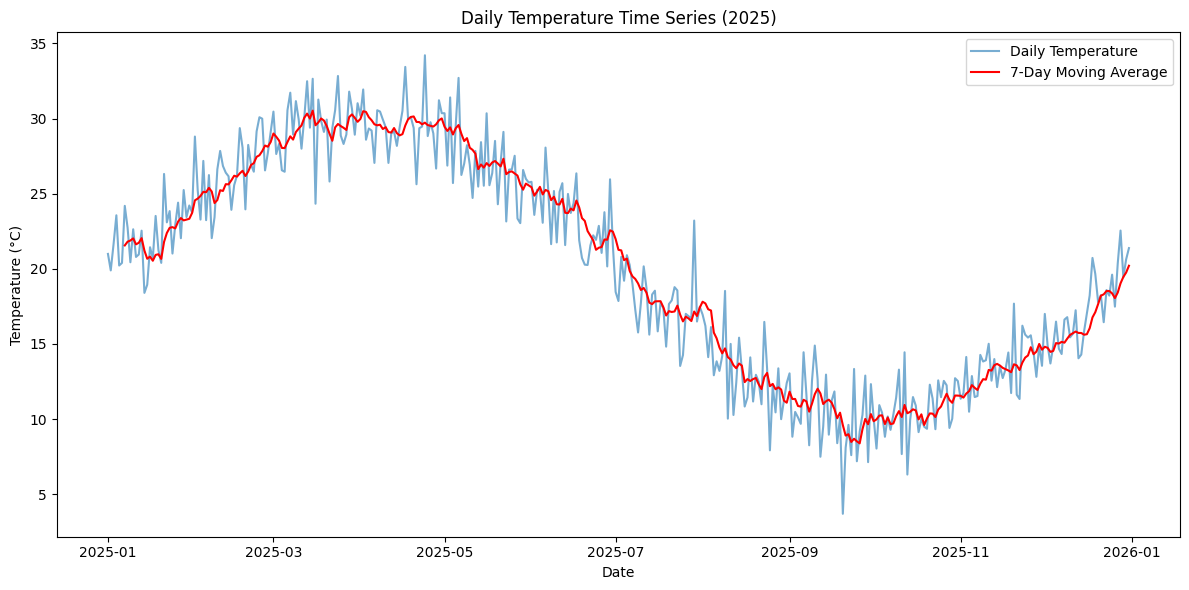

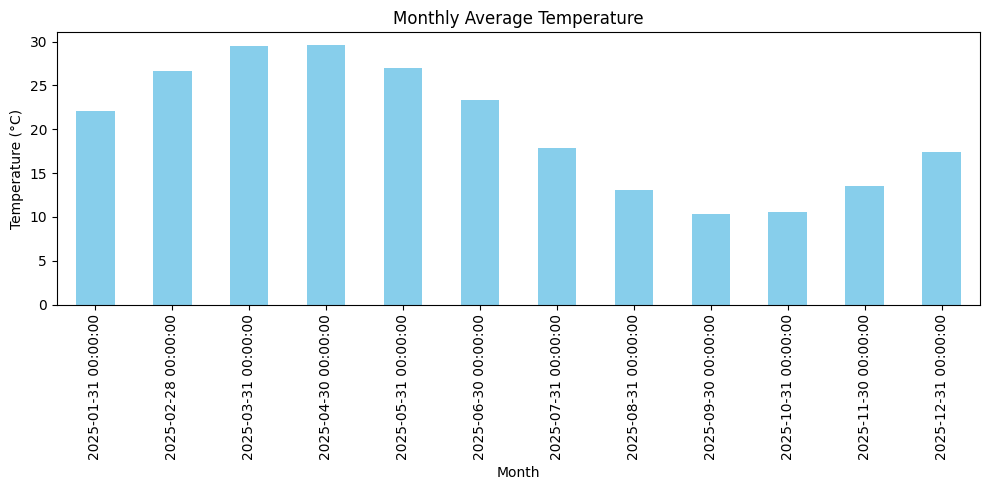

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Generate sample time series data (1 year)
# -----------------------------------
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')

# Generate synthetic temperature data using NumPy
np.random.seed(42)
temperatures = 20 + 10 * np.sin(np.linspace(0, 2 * np.pi, len(dates))) \
               + np.random.normal(0, 2, len(dates))

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Temperature': temperatures
})

# Set Date as index
df.set_index('Date', inplace=True)

print("First 5 rows:")
print(df.head())

# -----------------------------------
# Basic Analysis
# -----------------------------------
print("\nSummary Statistics:")
print(df['Temperature'].describe())

# Monthly average temperature
monthly_avg = df['Temperature'].resample('M').mean()
print("\nMonthly Average Temperature:")
print(monthly_avg)

# Rolling average (7-day moving average)
df['7-day MA'] = df['Temperature'].rolling(window=7).mean()

# -----------------------------------
# Visualization
# -----------------------------------
plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(df.index, df['Temperature'], label='Daily Temperature', alpha=0.6)

# Plot moving average
plt.plot(df.index, df['7-day MA'], label='7-Day Moving Average', color='red')

plt.title('Daily Temperature Time Series (2025)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------------
# Monthly Average Bar Plot
# -----------------------------------
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='skyblue')

plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

First 5 rows:
                 Close
Date                  
2025-01-01  101.043428
2025-01-02  100.814536
2025-01-03  102.170872
2025-01-06  105.334143
2025-01-07  104.893523

Basic Metrics:
Average Daily Return: 0.0005427938401257518
Volatility (Std Dev): 0.01950911558371005
Max Price: 113.11171272373575
Min Price: 79.04449139151173


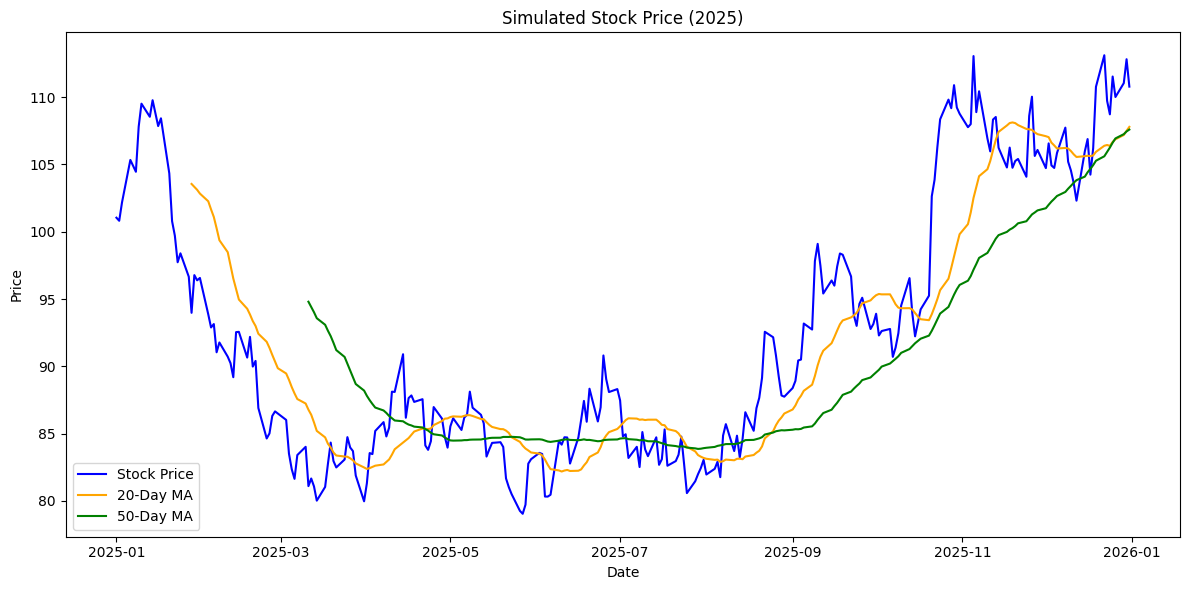

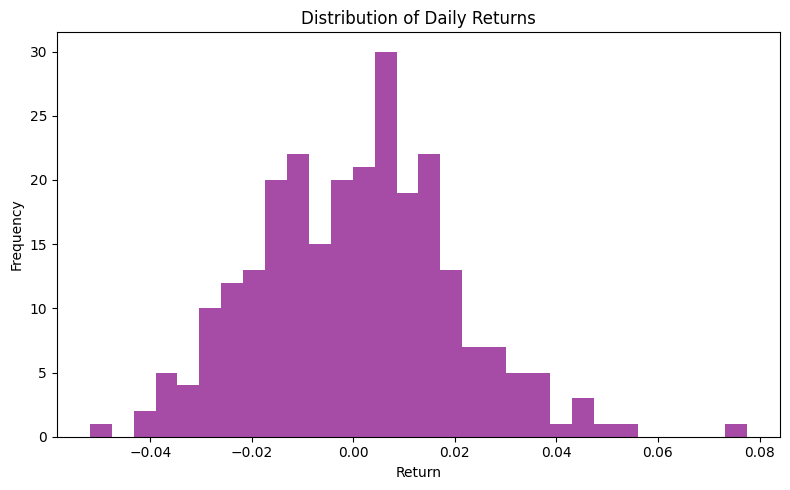

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Generate time series (1 year)
# -----------------------------------
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='B')  # Business days

# -----------------------------------
# Simulate stock prices using random walk
# -----------------------------------
np.random.seed(42)

initial_price = 100
returns = np.random.normal(loc=0.0005, scale=0.02, size=len(dates))  # daily returns

price = [initial_price]

for r in returns:
    price.append(price[-1] * (1 + r))

# Remove first extra value
price = price[1:]

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Close': price
})

df.set_index('Date', inplace=True)

print("First 5 rows:")
print(df.head())

# -----------------------------------
# Basic Metrics
# -----------------------------------
# Daily returns
df['Daily Return'] = df['Close'].pct_change()

# Average return
avg_return = df['Daily Return'].mean()

# Volatility (standard deviation)
volatility = df['Daily Return'].std()

# Max and Min prices
max_price = df['Close'].max()
min_price = df['Close'].min()

print("\nBasic Metrics:")
print("Average Daily Return:", avg_return)
print("Volatility (Std Dev):", volatility)
print("Max Price:", max_price)
print("Min Price:", min_price)

# -----------------------------------
# Moving Averages
# -----------------------------------
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# -----------------------------------
# Visualization
# -----------------------------------
plt.figure(figsize=(12, 6))

# Plot stock price
plt.plot(df.index, df['Close'], label='Stock Price', color='blue')

# Plot moving averages
plt.plot(df.index, df['MA_20'], label='20-Day MA', color='orange')
plt.plot(df.index, df['MA_50'], label='50-Day MA', color='green')

plt.title('Simulated Stock Price (2025)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------------
# Histogram of Returns
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.hist(df['Daily Return'].dropna(), bins=30, color='purple', alpha=0.7)

plt.title('Distribution of Daily Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# Import pandas
import pandas as pd

# -----------------------------------
# a. Create lists and DataFrame
# -----------------------------------
data = ['Apple', 'Banana', 'Mango', 'Orange', 'Grapes']
prices = [120, 60, 150, 80, 200]

# Zip lists and create DataFrame
fruits_df = pd.DataFrame(list(zip(data, prices)), columns=['Fruit', 'Price'])

# -----------------------------------
# b. Display DataFrame info
# -----------------------------------
print("DataFrame Info:")
print(fruits_df.info())

# -----------------------------------
# c. Print entire DataFrame
# -----------------------------------
print("\nFull DataFrame:")
print(fruits_df.to_string(index=False))

# -----------------------------------
# d. Descriptive statistics for Price
# -----------------------------------
print("\nDescriptive Statistics (Price):")
print(fruits_df['Price'].describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Fruit   5 non-null      object
 1   Price   5 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes
None

Full DataFrame:
 Fruit  Price
 Apple    120
Banana     60
 Mango    150
Orange     80
Grapes    200

Descriptive Statistics (Price):
count      5.00000
mean     122.00000
std       55.85696
min       60.00000
25%       80.00000
50%      120.00000
75%      150.00000
max      200.00000
Name: Price, dtype: float64
